# Individual Signal Evaluation (Task 4, Part 2)

For each candidate trust signal, train a separate logistic regression model using only that one
signal, and report its test-set ROC-AUC. This checks the project's own success criterion directly:
each signal should have *some* predictive power on its own (around 0.6 AUC or better), before any
of them are combined into an overall score.

Input: `data/train_split.csv` and `data/test_split.csv` from
`notebooks/002_build_dataset_and_split.ipynb` (84 train / 22 test repos, stratified, seed 42, no
repository overlap).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_DIR = "../data"

train_df = pd.read_csv(f"{DATA_DIR}/train_split.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test_split.csv")
len(train_df), len(test_df)

(84, 22)

## Method

For every signal column:

1. Take that one column as `X`, with `y = target_label` (1 = good, 0 = uncertain).
2. Fit a `SimpleImputer` (median) and `StandardScaler` on the **training split only**, then use
   them to transform both the training and test splits — the test set never influences
   preprocessing, only the final AUC score.
3. Fit a `LogisticRegression` on the scaled training data.
4. Score the fitted model's predicted probabilities against the held-out test labels with
   `roc_auc_score`.

Boolean columns (`has_license`, `is_org_owned`) go through the same pipeline; a single 0/1 feature
is still a valid (if blunt) input to logistic regression.

In [2]:
SIGNAL_COLUMNS = [
    "stargazers_count",
    "forks_count",
    "subscribers_count",
    "open_issues_count",
    "size",
    "age_days",
    "days_since_push",
    "fork_star_ratio",
    "subscriber_star_ratio",
    "issues_per_star",
    "stars_per_day",
    "has_license",
    "is_org_owned",
    "contributor_activity_ratio",
    "ghost_contributor_ratio",
]

y_train = train_df["target_label"]
y_test = test_df["target_label"]


def evaluate_signal(column: str) -> float:
    features_train = train_df[[column]].astype(float)
    features_test = test_df[[column]].astype(float)

    pipeline = Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(random_state=42, max_iter=1000)),
        ]
    )
    pipeline.fit(features_train, y_train)

    predicted_probabilities = pipeline.predict_proba(features_test)[:, 1]
    return roc_auc_score(y_test, predicted_probabilities)


results = pd.DataFrame(
    [{"signal": column, "test_auc": evaluate_signal(column)} for column in SIGNAL_COLUMNS]
).sort_values("test_auc", ascending=False, ignore_index=True)
results["reaches_0.6"] = results["test_auc"] >= 0.6
results

,signal,test_auc,reaches_0.6
0,age_days,0.988235,True
1,subscriber_star_ratio,0.964706,True
2,subscribers_count,0.941176,True
3,open_issues_count,0.905882,True
4,size,0.847059,True
5,forks_count,0.835294,True
6,stars_per_day,0.835294,True
7,issues_per_star,0.823529,True
8,contributor_activity_ratio,0.823529,True
9,fork_star_ratio,0.800000,True


## Results

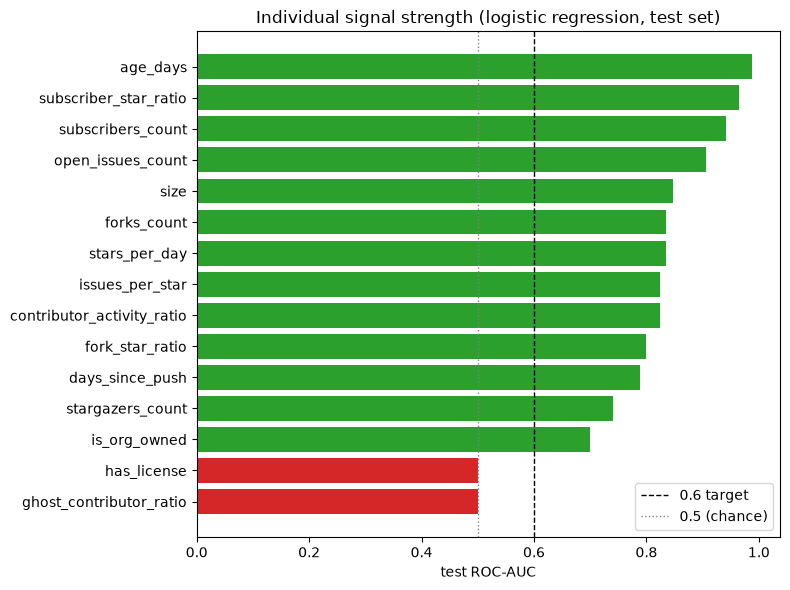

13 / 15 signals reach 0.6 or higher test AUC


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["tab:green" if auc >= 0.6 else "tab:red" for auc in results["test_auc"]]
ax.barh(results["signal"], results["test_auc"], color=colors)
ax.axvline(0.6, color="black", linestyle="--", linewidth=1, label="0.6 target")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1, label="0.5 (chance)")
ax.invert_yaxis()
ax.set_xlabel("test ROC-AUC")
ax.set_title("Individual signal strength (logistic regression, test set)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"{results['reaches_0.6'].sum()} / {len(results)} signals reach 0.6 or higher test AUC")

## Strongest and weakest signals

**Strongest: `age_days` (0.988) and `subscriber_star_ratio` (0.965).** An older repo, and one
where a larger share of its stargazers also bother to watch it, is overwhelmingly likely to be in
the good class on this dataset. Both match the strongest signals found in Task 1's exploratory
analysis on the same features (AUC 0.972 and 0.961 there, using a rank-based statistic rather than
a fitted model) — a useful cross-check that this split and this modeling approach reproduce the
same underlying pattern rather than an artifact of one method.

Three raw counts (`subscribers_count`, `open_issues_count`, `size`) and most of the engineered
ratios also comfortably clear 0.6, which is consistent with Task 1's finding that ratio-based
signals tend to separate the classes better than raw stars/forks alone, though here several raw
counts do well too once logistic regression fits a model to them directly.

One pattern worth flagging: `stars_per_day` and `days_since_push` score well here (0.835 and
0.788) despite reading as *weak, inversely-related* signals in Task 1's own rank-based analysis
(0.190 and 0.154 there). That is not a contradiction — logistic regression fits a sign for each
feature automatically, so a signal that is strongly predictive in the "uncertain repos score
higher" direction still produces a high AUC here, while the earlier rank statistic reported in
Task 1 was deliberately directional (P(good scores higher than uncertain) without correcting
sign). Both are measuring the same underlying separation; a fitted model just doesn't care which
direction it runs.

**Weakest: `has_license` and `ghost_contributor_ratio`, both exactly 0.500.** These are not
useless signals as much as they are small-sample artifacts of this particular split:
`has_license` has only one `False` value in the entire 106-repo dataset, and it happened to land
in the training set, so every repo in the 22-row test set has the same value (`True`) — the model
can't be evaluated on a feature with zero variance in the holdout set. `ghost_contributor_ratio`
has the same problem for a more structural reason: across the full dataset only 3 of 106 repos had
any flagged contributor at all (see `notebooks/004_ghost_contributor_detection.ipynb`), so a
22-repo test set landing all-zero on this column is close to guaranteed regardless of which repos
end up in it. The fuller 106-repo analysis in that notebook already established this signal's AUC
is near chance (0.491) on its own terms, so the 0.500 here is consistent, not surprising — but the
`has_license` result specifically should be read as "not evaluable at this test-set size," not as
evidence the signal doesn't work.

**Headline result:** 13 of 15 individual signals reach the project's ~0.6 AUC target on their own,
well above the "some predictive power" bar from the project's success criteria, with several
clearing 0.9. That is a strong starting point for combining them into an overall model.